In [3]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [4]:
sns.set_style("whitegrid")

In [5]:
df = pd.read_excel("student_dataset.xlsx")
df.head()

,student_id,age,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,label
0,STU00001,26,2024-01-13,0,3,5,0.3571,5.29,10,5,0
1,STU00002,23,2024-05-05,0,6,0,0.0000,0.84,7,0,1
2,STU00003,17,2024-03-12,0,3,1,0.0435,1.79,36,0,1
3,STU00004,23,2024-12-12,0,6,13,0.4396,0.78,9,0,1
4,STU00005,20,2024-02-14,0,5,5,0.2078,0.92,11,0,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   student_id              5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   enroll_date             5000 non-null   object 
 3   exam_season             5000 non-null   int64  
 4   courses_enrolled        5000 non-null   int64  
 5   completed_assignments   5000 non-null   int64  
 6   completion_rate         5000 non-null   float64
 7   login_frequency         5000 non-null   float64
 8   last_activity_days_ago  5000 non-null   int64  
 9   forum_posts_count       5000 non-null   int64  
 10  label                   5000 non-null   int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 429.8+ KB


In [7]:
df["enroll_date"] = pd.to_datetime(df["enroll_date"])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   student_id              5000 non-null   object        
 1   age                     5000 non-null   int64         
 2   enroll_date             5000 non-null   datetime64[ns]
 3   exam_season             5000 non-null   int64         
 4   courses_enrolled        5000 non-null   int64         
 5   completed_assignments   5000 non-null   int64         
 6   completion_rate         5000 non-null   float64       
 7   login_frequency         5000 non-null   float64       
 8   last_activity_days_ago  5000 non-null   int64         
 9   forum_posts_count       5000 non-null   int64         
 10  label                   5000 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(7), object(1)
memory usage: 429.8+ KB


In [9]:
df["enroll_month"] = pd.to_datetime(df["enroll_date"]).dt.month
df["enroll_dayofweek"] = pd.to_datetime(df["enroll_date"]).dt.dayofweek

In [11]:
df.head(3)

,student_id,age,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,label,enroll_month,enroll_dayofweek
0,STU00001,26,2024-01-13,0,3,5,0.3571,5.29,10,5,0,1,5
1,STU00002,23,2024-05-05,0,6,0,0.0000,0.84,7,0,1,5,6
2,STU00003,17,2024-03-12,0,3,1,0.0435,1.79,36,0,1,3,1


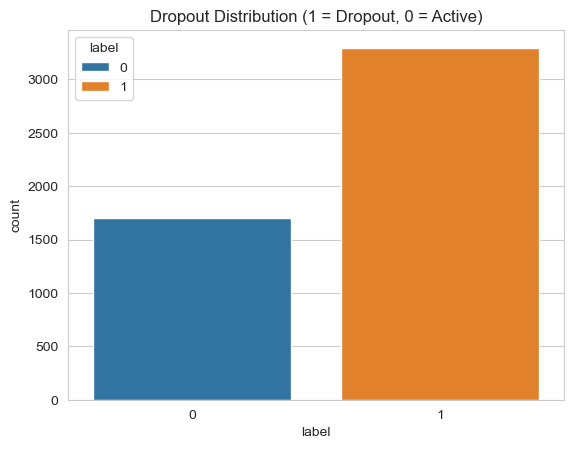

In [13]:
sns.countplot(x="label", data=df, hue='label')
plt.title("Dropout Distribution (1 = Dropout, 0 = Active)")
plt.show()

In [17]:
df["label"].value_counts(normalize = True) * 100

label
1    65.92
0    34.08
Name: proportion, dtype: float64

In [18]:
df.columns

Index(['student_id', 'age', 'enroll_date', 'exam_season', 'courses_enrolled',
       'completed_assignments', 'completion_rate', 'login_frequency',
       'last_activity_days_ago', 'forum_posts_count', 'label', 'enroll_month',
       'enroll_dayofweek'],
      dtype='object')

In [23]:
num_cols = ['age', 'courses_enrolled', 'completed_assignments', 'completion_rate', 'login_frequency',
       'last_activity_days_ago', 'forum_posts_count']

In [24]:
num_cols

['age',
 'courses_enrolled',
 'completed_assignments',
 'completion_rate',
 'login_frequency',
 'last_activity_days_ago',
 'forum_posts_count']

In [25]:
df[num_cols]

,age,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count
0,26,3,5,0.3571,5.29,10,5
1,23,6,0,0.0000,0.84,7,0
2,17,3,1,0.0435,1.79,36,0
3,23,6,13,0.4396,0.78,9,0
4,20,5,5,0.2078,0.92,11,0
...,...,...,...,...,...,...,...
4995,26,2,7,0.6537,11.06,1,14
4996,34,2,3,0.2559,5.16,15,3
4997,18,3,3,0.2242,5.05,5,6
4998,24,1,1,0.2659,4.04,1,4


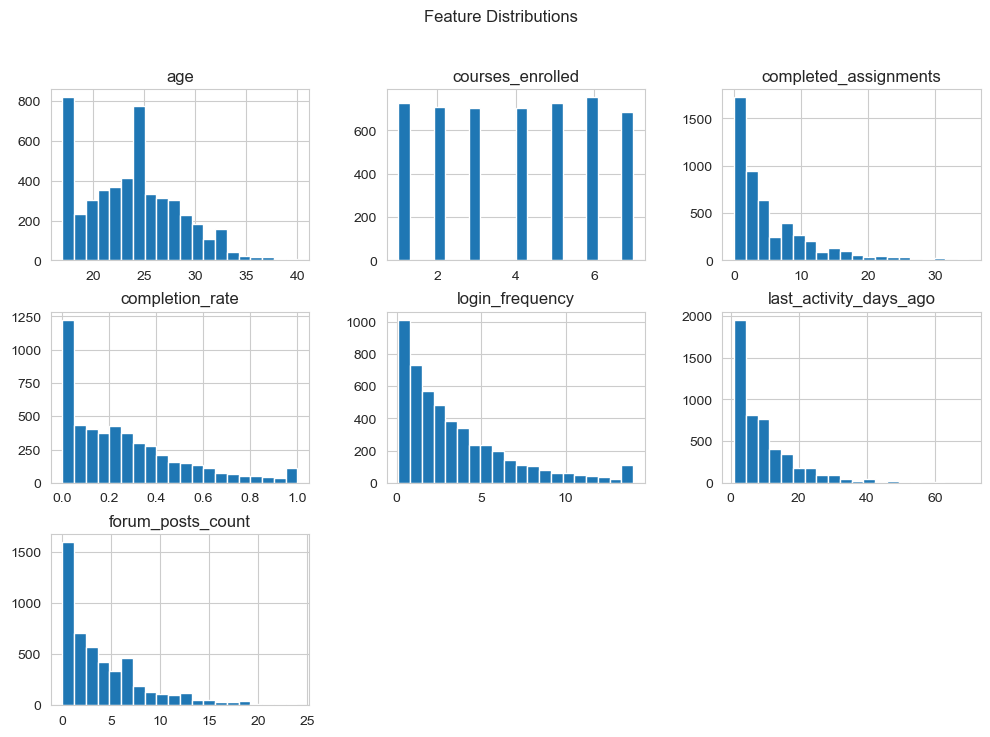

In [27]:
df[num_cols].hist(bins=20, figsize=(12,8))
plt.suptitle("Feature Distributions")
plt.show()

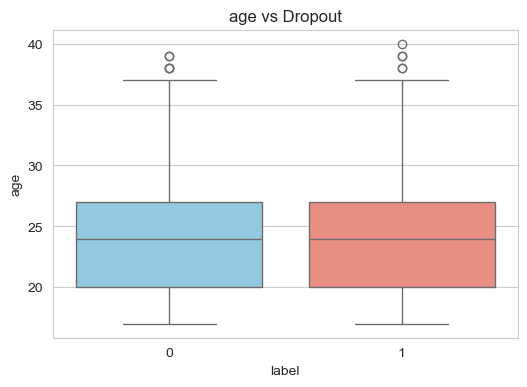

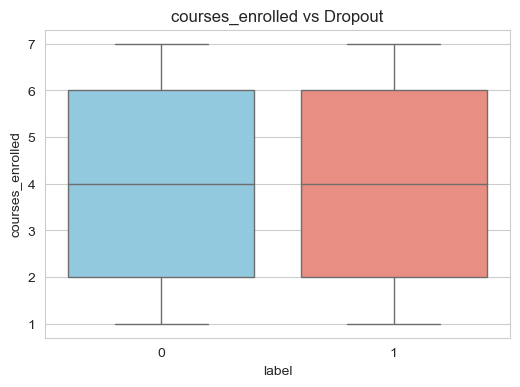

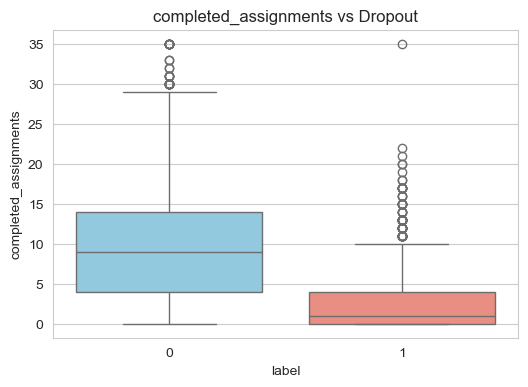

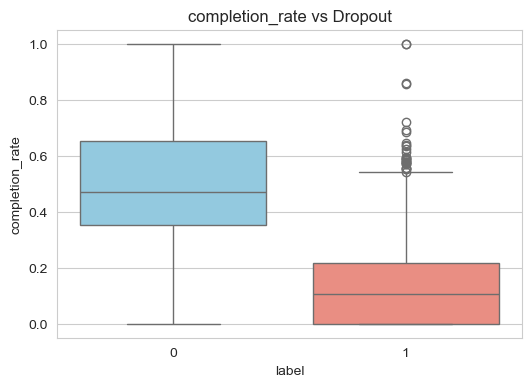

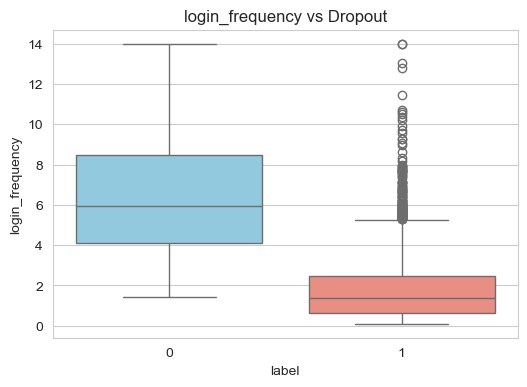

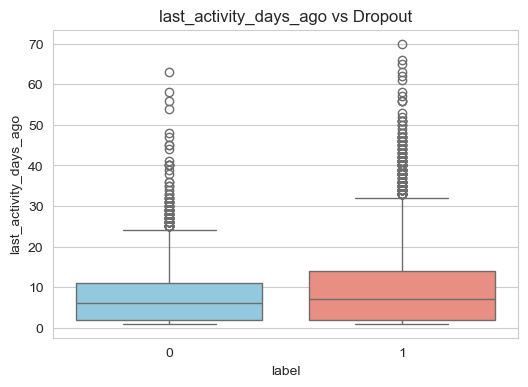

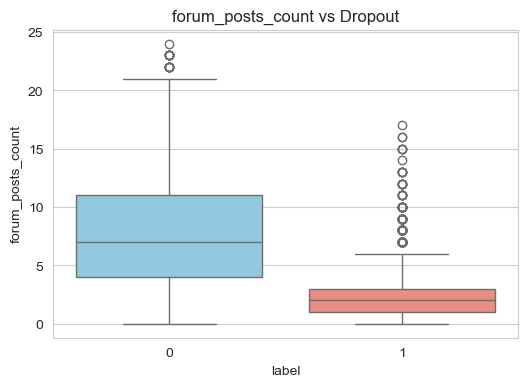

In [32]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="label", y = col, data = df, hue="label", palette=["skyblue", "salmon"], legend=False)
    # label col is not there in the df[num_cols] hence we take data=df not df[num_cols]
    plt.title(f"{col} vs Dropout")
    plt.show()

In [34]:
num_cols + ["label"]

['age',
 'courses_enrolled',
 'completed_assignments',
 'completion_rate',
 'login_frequency',
 'last_activity_days_ago',
 'forum_posts_count',
 'label']

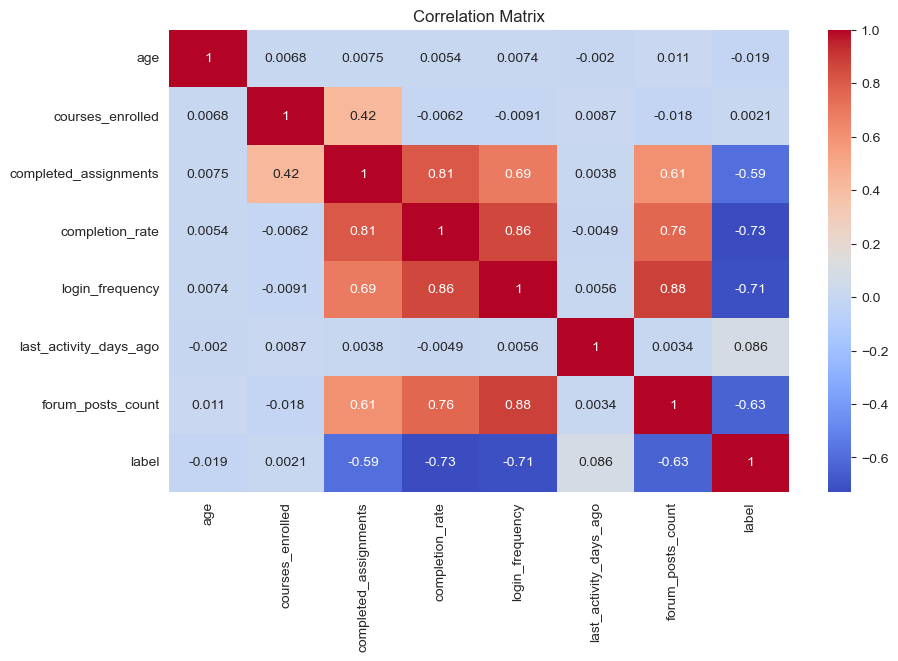

In [33]:
plt.figure(figsize=(10,6))

sns.heatmap(df[num_cols + ["label"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [39]:
grouped = df.groupby("label")[num_cols].mean()
grouped

,age,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count
label,,,,,,,
0,23.856808,3.993545,10.214789,0.512990,6.668122,8.231808,7.980634
1,23.674454,4.002427,2.589806,0.130701,1.792057,9.937803,2.263956


In [38]:
df.groupby("label")[num_cols].sum()


,age,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count
label,,,,,,,
0,40652,6805,17406,874.1344,11362.48,14027,13599
1,78031,13192,8536,430.7918,5906.62,32755,7462


In [40]:
grouped.T

label,0,1
age,23.856808,23.674454
courses_enrolled,3.993545,4.002427
completed_assignments,10.214789,2.589806
completion_rate,0.512990,0.130701
login_frequency,6.668122,1.792057
last_activity_days_ago,8.231808,9.937803
forum_posts_count,7.980634,2.263956


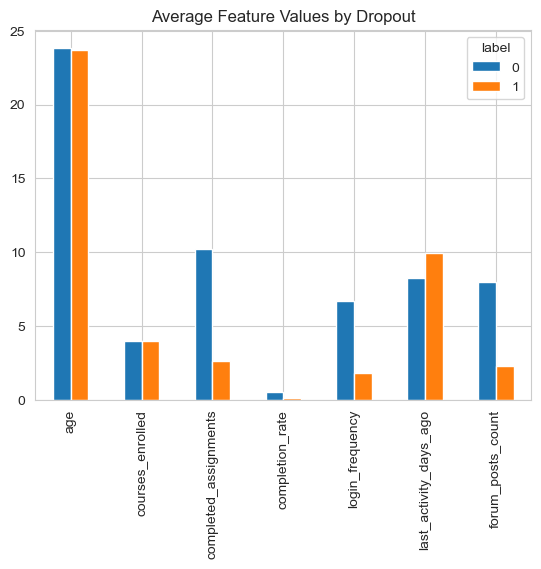

In [41]:
grouped.T.plot(kind="bar")
plt.title("Average Feature Values by Dropout")
plt.show()

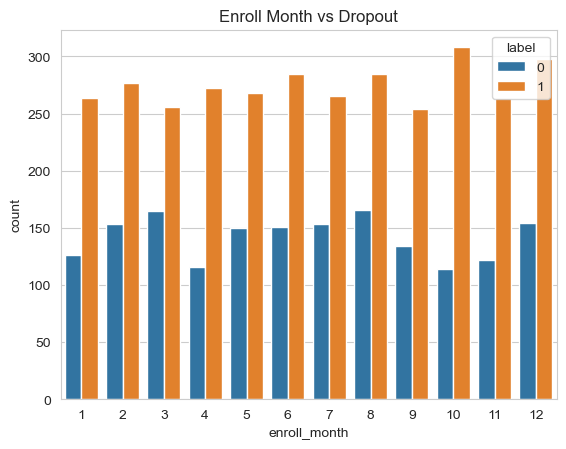

In [44]:
sns.countplot(x="enroll_month", hue="label", data=df)
plt.title("Enroll Month vs Dropout")
plt.show()

In [45]:
df.head(2)

,student_id,age,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,label,enroll_month,enroll_dayofweek
0,STU00001,26,2024-01-13,0,3,5,0.3571,5.29,10,5,0,1,5
1,STU00002,23,2024-05-05,0,6,0,0.0000,0.84,7,0,1,5,6


In [47]:
df["engagement_score"] = (df["login_frequency"] * 0.4 + df["completion_rate"] * 0.4 + df["forum_posts_count"] * 0.2)
df["engagement_score"]

0       3.25884
1       0.33600
2       0.73340
3       0.48784
4       0.45112
         ...   
4995    7.48548
4996    2.76636
4997    3.30968
4998    2.52236
4999    2.00164
Name: engagement_score, Length: 5000, dtype: float64

In [48]:
df.head(2)

,student_id,age,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,label,enroll_month,enroll_dayofweek,engagement_score
0,STU00001,26,2024-01-13,0,3,5,0.3571,5.29,10,5,0,1,5,3.25884
1,STU00002,23,2024-05-05,0,6,0,0.0000,0.84,7,0,1,5,6,0.33600


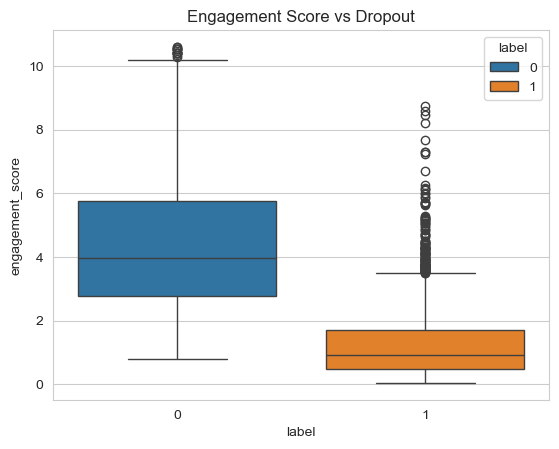

In [50]:
sns.boxplot(x = "label", y = "engagement_score", data = df, hue="label")
plt.title("Engagement Score vs Dropout")
plt.show()

### Features Selection

In [51]:
df.columns

Index(['student_id', 'age', 'enroll_date', 'exam_season', 'courses_enrolled',
       'completed_assignments', 'completion_rate', 'login_frequency',
       'last_activity_days_ago', 'forum_posts_count', 'label', 'enroll_month',
       'enroll_dayofweek', 'engagement_score'],
      dtype='object')

In [52]:
features = [
    "completion_rate",
    "login_frequency",
    "last_activity_days_ago",
    "courses_enrolled",
    "forum_posts_count"
]

In [54]:
X = df[features]
X

,completion_rate,login_frequency,last_activity_days_ago,courses_enrolled,forum_posts_count
0,0.3571,5.29,10,3,5
1,0.0000,0.84,7,6,0
2,0.0435,1.79,36,3,0
3,0.4396,0.78,9,6,0
4,0.2078,0.92,11,5,0
...,...,...,...,...,...
4995,0.6537,11.06,1,2,14
4996,0.2559,5.16,15,2,3
4997,0.2242,5.05,5,3,6
4998,0.2659,4.04,1,1,4


In [55]:
y = df["label"]
y

0       0
1       1
2       1
3       1
4       1
       ..
4995    0
4996    1
4997    0
4998    0
4999    0
Name: label, Length: 5000, dtype: int64

### Train_Test_Split

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [59]:
rf = RandomForestClassifier()

In [61]:
rf_params = {
    "n_estimators" : [100, 200],
    "max_depth" : [4, 6, 8 ],
    "min_samples_split" : [2, 5],
    "min_samples_leaf" : [1,2]

}

In [63]:
rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv = 3,
    scoring = "accuracy",
    n_jobs = -1
    
)

In [64]:
rf_grid.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [4, 6, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [69]:
best_rf = rf_grid.best_estimator_

print("Best RF Parametrs:", rf_grid.best_params_)

Best RF Parametrs: {'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [70]:
from xgboost import XGBClassifier

In [71]:
xgb = XGBClassifier(
    eval_metric = "logloss",
    use_label_encoder = False,
)


In [72]:
xgb_params = {
    "n_estimators" : [100, 200],
    "max_depth" : [3, 5, 7 ],
    "learning_rate" : [0.05, 0.1],
    "subsample" : [0.8, 1]

}

In [73]:
xgb_grid = GridSearchCV(
    xgb,
    xgb_params,
    cv = 3,
    scoring = "accuracy",
    n_jobs = -1
)


In [75]:
xgb_grid.fit(X_train, y_train)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], 'subsample': [0.8, 1]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [78]:
best_xgb = xgb_grid.best_estimator_

print("Best XGB Parametrs:", xgb_grid.best_params_)

Best XGB Parametrs: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1}


In [79]:
from sklearn.metrics import accuracy_score

In [80]:
def evaluate_model(model, X_test, y_test, name):
    preds = model.predict(X_test)
    print(f" {name} Results:")
    print("Accuracy:", accuracy_score(y_test, preds))
    
    

In [81]:
evaluate_model(best_rf, X_test, y_test, "Random Forest")
evaluate_model(best_xgb, X_test, y_test, "XGBoost")

 Random Forest Results:
Accuracy: 0.924
 XGBoost Results:
Accuracy: 0.921


In [82]:
features

['completion_rate',
 'login_frequency',
 'last_activity_days_ago',
 'courses_enrolled',
 'forum_posts_count']

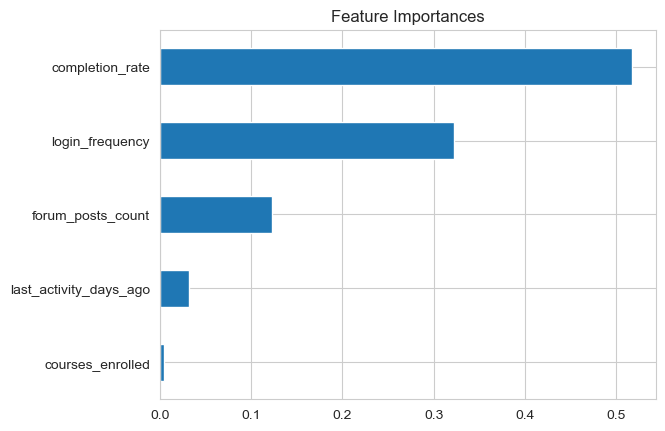

In [83]:
rf_importance = pd.Series(best_rf.feature_importances_, features)
rf_importance.sort_values().plot(kind = "barh", title= "Feature Importances")
plt.show()

In [84]:
import joblib

In [85]:
best_model = best_rf

In [86]:
joblib.dump(best_model, "student_dropout_model.pkl")

['student_dropout_model.pkl']

In [87]:
joblib.dump(features, "model_features.pkl")

['model_features.pkl']